This notebook demonstrates tokenization, embeddings, attention visualization, generation controls, distillation, and inference speed comparison.

In [ ]:

!pip install torch transformers sentencepiece matplotlib seaborn


In [ ]:

import torch, time
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM


## Tokenization

In [ ]:

tokenizer = AutoTokenizer.from_pretrained("gpt2")
text = "what is kubernetes"
tokens = tokenizer.tokenize(text)
ids = tokenizer.encode(text)
tokens, ids


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

(['what', 'Ġis', 'Ġk', 'uber', 'net', 'es'],
 [10919, 318, 479, 18478, 3262, 274])

## Embeddings + Positional Embeddings

In [ ]:

model = AutoModelForCausalLM.from_pretrained("gpt2", output_attentions=True)
input_ids = torch.tensor([ids])
token_emb = model.transformer.wte(input_ids)
pos_emb = model.transformer.wpe(torch.arange(input_ids.shape[1]))
(token_emb + pos_emb).shape

print("Token Embeddings:")
print(token_emb)
print("\nPositional Embeddings:")
print(pos_emb)


Token Embeddings:
tensor([[[ 0.0074, -0.0905,  0.0956,  ...,  0.3158,  0.0548, -0.0087],
         [-0.0097,  0.0101,  0.0556,  ...,  0.1145, -0.0380, -0.0254],
         [ 0.0850, -0.1046,  0.0975,  ...,  0.0276,  0.0911,  0.1052],
         [-0.2312, -0.1863, -0.0121,  ...,  0.2383, -0.1629,  0.1040],
         [ 0.1228,  0.0675, -0.0672,  ...,  0.0836,  0.0866, -0.0984],
         [-0.2033,  0.0500,  0.2055,  ...,  0.0489, -0.0631,  0.0457]]],
       grad_fn=<EmbeddingBackward0>)

Positional Embeddings:
tensor([[-1.8821e-02, -1.9742e-01,  4.0267e-03,  ..., -4.3044e-02,
          2.8267e-02,  5.4490e-02],
        [ 2.3959e-02, -5.3792e-02, -9.4879e-02,  ...,  3.4170e-02,
          1.0172e-02, -1.5573e-04],
        [ 4.2161e-03, -8.4764e-02,  5.4515e-02,  ...,  1.9745e-02,
          1.9325e-02, -2.1424e-02],
        [-2.8337e-04, -7.3803e-02,  1.0553e-01,  ...,  1.0157e-02,
          1.7659e-02, -7.0854e-03],
        [ 7.6374e-03, -2.5090e-02,  1.2696e-01,  ...,  8.4643e-03,
          9.85

## Attention Heatmap

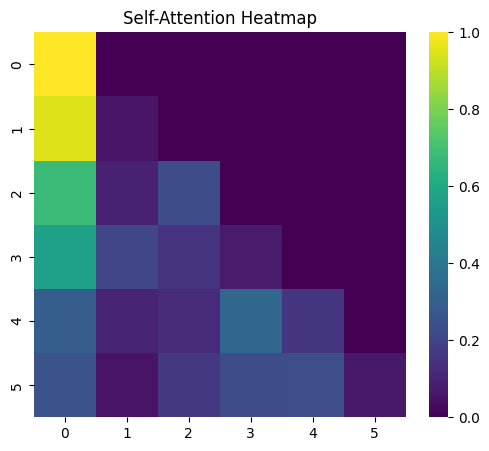

In [ ]:

with torch.no_grad():
    outputs = model(input_ids)
attn = outputs.attentions[0][0][0]  # layer 0, head 0
plt.figure(figsize=(6,5))
sns.heatmap(attn, cmap="viridis")
plt.title("Self-Attention Heatmap")
plt.show()


## Text Generation: Temperature Comparison

In [ ]:

for t in [ 2, 1.2]:
    out = model.generate(input_ids, max_new_tokens=30, temperature=t)
    print(f"Temperature={t}:")
    print(tokenizer.decode(out[0]))
    print("-"*50)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Temperature=2:
what is kubernetes?

Kubernetes is a web application that allows you to create and manage your own virtual machines. It is a great way to get
--------------------------------------------------
Temperature=1.2:
what is kubernetes?

Kubernetes is a web application that allows you to create and manage your own virtual machines. It is a great way to get
--------------------------------------------------


## Hard-label Distillation (Tiny Demo)

In [ ]:

teacher = AutoModelForCausalLM.from_pretrained("gpt2-large")
student = AutoModelForCausalLM.from_pretrained("gpt2")

teacher.eval()
student.train()

with torch.no_grad():
    teacher_logits = teacher(input_ids).logits

teacher_tokens = torch.argmax(teacher_logits, dim=-1)
loss_fn = torch.nn.CrossEntropyLoss()
student_logits = student(input_ids).logits
loss = loss_fn(student_logits.view(-1, student_logits.size(-1)), teacher_tokens.view(-1))
loss

print(tokenizer.decode(teacher_tokens[0]))



 you theratomnetes?


## Soft-label Distillation (Toy Example)

In [ ]:

T = 2.0
teacher_probs = torch.softmax(teacher_logits / T, dim=-1)
student_probs = torch.softmax(student_logits / T, dim=-1)

kl = torch.nn.KLDivLoss(reduction="batchmean")
kl(torch.log(student_probs), teacher_probs)


tensor(4.6434, grad_fn=<DivBackward0>)

## Inference Speed Comparison

In [ ]:

def measure(model, name):
    start = time.time()
    for _ in range(5):
        model.generate(input_ids, max_new_tokens=20)
    print(f"{name} time:", time.time() - start)

measure(teacher, "Teacher (GPT-2 Large)")
measure(student, "Student (GPT-2)")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generati

Teacher (GPT-2 Large) time: 37.13567399978638


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generati

Student (GPT-2) time: 6.906673908233643


## Summary
This notebook demonstrates end-to-end LLM internals, decoding controls, attention visualization, and distillation concepts.